In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from pathlib import Path

In [3]:
# for package auto reload
%load_ext autoreload
%autoreload 2

# for better rendering of plots in jupyter notebook
%matplotlib inline

# base modules
from pathlib import Path

# for manipulating data
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

# for Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report


# for visualization
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
path_to_repo = Path('..').resolve()
path_to_data = path_to_repo / 'data'

In [5]:
df = pd.read_csv(path_to_data / 'preprocessed_data.csv')

In [6]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,EXPERIENCE,LOG_INCOME,bad
0,5008804,1,1,1,0,4,1,0,4,1,1,0,0,2,32,12,12.965712,0
1,5008805,1,1,1,0,4,1,0,4,1,1,0,0,2,32,12,12.965712,0
2,5008806,1,1,1,0,4,4,1,1,1,0,0,0,2,58,3,11.630717,0
3,5008808,0,0,1,0,0,4,3,1,1,0,1,1,1,52,8,12.506181,0
4,5008809,0,0,1,0,0,4,3,1,1,0,1,1,1,52,8,12.506181,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,1,1,1,0,4,4,1,1,1,0,0,0,2,47,6,12.660331,1
36453,5149834,0,0,1,0,0,1,1,1,1,0,1,1,2,33,3,11.967187,1
36454,5149838,0,0,1,0,1,1,1,1,1,0,1,1,2,33,3,11.967187,1
36455,5150049,0,0,1,0,4,4,1,1,1,0,0,0,2,49,1,12.554971,1


In [7]:
y = df["bad"]
X = df.drop(columns=["bad", "ID"])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
rf_default = RandomForestClassifier(random_state=42)
%time rf_default.fit(X_train, y_train)

CPU times: user 986 ms, sys: 19.5 ms, total: 1.01 s
Wall time: 1.01 s


RandomForestClassifier(random_state=42)

In [17]:
y_pred_default = rf_default.predict(X_test)
y_prob_default = rf_default.predict_proba(X_test)[:, 1]

In [13]:
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7169
           1       0.33      0.14      0.19       123

    accuracy                           0.98      7292
   macro avg       0.66      0.57      0.59      7292
weighted avg       0.97      0.98      0.98      7292



In [ ]:
rf_default = RandomForestClassifier(random_state=42,
                                    class_weight='balanced')
%time rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)
y_prob_default = rf_default.predict_proba(X_test)[:, 1]

CPU times: user 973 ms, sys: 9.92 ms, total: 983 ms
Wall time: 983 ms


RandomForestClassifier(class_weight='balanced', random_state=42)

In [18]:
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.17      0.35      0.23       123

    accuracy                           0.96      7292
   macro avg       0.58      0.66      0.60      7292
weighted avg       0.97      0.96      0.97      7292



In [21]:
rf_default = RandomForestClassifier(random_state=42,
                                    class_weight='balanced_subsample')
%time rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)
y_prob_default = rf_default.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_default))

CPU times: user 1.14 s, sys: 12.5 ms, total: 1.16 s
Wall time: 1.16 s
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.17      0.37      0.24       123

    accuracy                           0.96      7292
   macro avg       0.58      0.67      0.61      7292
weighted avg       0.98      0.96      0.97      7292



# GridSearch

In [23]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

In [24]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, scoring='f1_macro', verbose=0)
%time grid_search.fit(X_train, y_train)

CPU times: user 1.61 s, sys: 562 ms, total: 2.17 s
Wall time: 1min 49s


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 7, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1_macro')

In [25]:
best_rf = grid_search.best_estimator_
y_pred_gs = best_rf.predict(X_test)
y_prob_gs = best_rf.predict_proba(X_test)[:, 1]

In [31]:
print(classification_report(y_test, y_pred_gs))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.19      0.37      0.25       123

    accuracy                           0.96      7292
   macro avg       0.59      0.67      0.61      7292
weighted avg       0.98      0.96      0.97      7292



# SMOTE

In [27]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [28]:
rf_smote = RandomForestClassifier(class_weight='balanced_subsample', 
                                    min_samples_split=10,
                                    n_estimators=50, 
                                    random_state=42
                                )
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

In [30]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7169
           1       0.20      0.22      0.21       123

    accuracy                           0.97      7292
   macro avg       0.59      0.60      0.60      7292
weighted avg       0.97      0.97      0.97      7292



In [32]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_default)

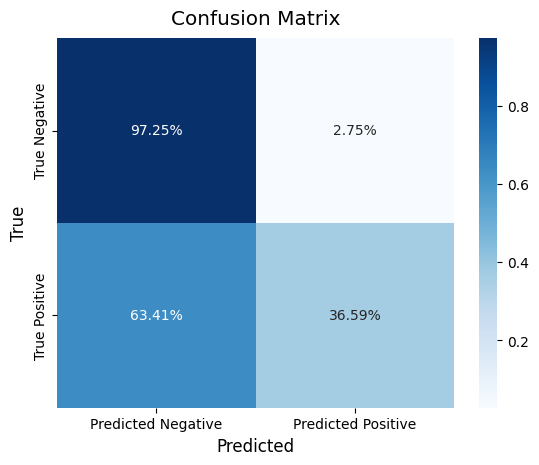

In [37]:
# Compute confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_gs, normalize='true')
# Plot with seaborn
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels = ['Predicted Negative', 'Predicted Positive'], yticklabels = ['True Negative', 'True Positive'])
plt.xlabel("Predicted", size="large")
plt.ylabel("True", size="large")
plt.title("Confusion Matrix", size="x-large", pad=10)
plt.show()